# HealthConnect Clinic — Week 6: ML Pipeline Integration & Validation

**Intern:** Grai Rudolf
**Role:** Junior Machine Learning Engineer
**Track:** Machine Learning Engineering
**Project:** HealthConnect Clinic Experience Lab
**Date:** September 2026

---

## Executive Summary

This notebook documents the **Week 6** practical implementation of the HealthConnect ML
Engineering track. Building directly on the Week 5 pipeline, Week 6 delivers:

1. **Improved model configurations** with tuned hyperparameters (higher n_estimators,
   adjusted depth, cost-sensitive learning).
2. **Input and output validation** checks (`validation.py`) ensuring data schemas and
   prediction outputs are correct before and after pipeline execution.
3. **Proper logging** replacing raw print statements throughout the pipeline.
4. **An integrated end-to-end pipeline** (`model_integration.py`) that wraps
   load → clean → engineer → preprocess → train → predict into a single callable class.
5. **Integration testing** that validates the full pipeline flow from raw data through to
   risk-stratified predictions.
6. **Cross-track collaboration** with the Data Science track — integrating the candidate
   model interface into the pipeline.

The focus is on **integration and validation**, not final production deployment
(which is deferred to Week 7/8).

---
## 1. Week 5 → Week 6 Transition

| Aspect | Week 5 | Week 6 |
|---|---|---|
| Main output | Modular pipeline package | Integrated end-to-end pipeline |
| Key result | Logistic Regression baseline recall 0.650 | Improved models, integrated pipeline |
| Main limitation | No validation checks, no logging, no integration testing | Added validation, logging, integration tests |
| Track dependency | Identified Data Science track | Actively integrated DS candidate model |
| Week 5 focus | What should we do? | Improve → Integrate → Validate

---
## 2. Week 6 Pipeline Improvements

### 2.1 Validation Checks (`pipeline/validation.py`)
Added schema and output validation:
- `validate_raw_data()` — checks required columns exist and minimum row count.
- `validate_clean_data()` — checks binary target, no leakage columns, no nulls.
- `validate_features()` — checks engineered features are present.
- `validate_prediction_output()` — checks prediction DataFrame has correct schema,
  probabilities in [0, 1], and valid risk tiers.
- `validate_feature_names()` — checks the preprocessor can extract feature names.

### 2.2 Logging
Replaced all `print()` statements with structured `logging` calls using the
`pipeline.config.logger` instance. Log level is configurable via `LOG_LEVEL` env var.

### 2.3 Improved Model Configurations (`pipeline/model_training.py`)
Based on Week 5 error analysis and cross-track input from Data Science, the Week 6
improved models use:
- **Random Forest:** 500 trees (up from 200), `max_depth=12`, `min_samples_leaf=5`.
- **Gradient Boosting:** 300 trees, `learning_rate=0.05`, `subsample=0.8`.
- **LightGBM:** 400 trees, `learning_rate=0.05`, `colsample_bytree=0.8`.
- All retain `class_weight='balanced'` for cost-sensitive recall focus.

### 2.4 Integrated Pipeline (`model_integration.py`)
`HealthConnectPipeline` class wraps the full flow:
```python
pipe = HealthConnectPipeline(threshold=0.50)
results = pipe.run(model_name="Random Forest")
pred = pipe.predict_single(record)
pipe.save_artifacts("artifacts")
```
Handles load → clean → engineer → preprocess → train → predict, with validation
checks at each boundary.

---
## 3. Environment & Data

In [1]:
import sys, os, warnings
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from pipeline.model_integration import HealthConnectPipeline
from pipeline.model_training import get_baseline_models, get_improved_models, train_models
from pipeline.data_processing import load_data, clean_data, build_preprocessing_pipeline, get_feature_names
from pipeline.feature_engineering import engineer_features
from pipeline.evaluation import evaluate_model, plot_model_comparison, plot_confusion_matrix, plot_roc_curve, plot_feature_importance
from pipeline.validation import validate_raw_data, validate_clean_data, validate_features, validate_prediction_output
from sklearn.model_selection import train_test_split
from pipeline.config import TEST_SIZE, RANDOM_STATE, FIGURES_DIR

plt.style.use('ggplot')
print("Week 6 pipeline modules imported successfully.")

Week 6 pipeline modules imported successfully.


---
## 4. Validation Checks in Action

In [2]:
raw = load_data()
validate_raw_data(raw)

2026-09-09 14:54:49 [healthconnect.pipeline] INFO: Dataset loaded: 5000 rows, 18 columns


2026-09-09 14:54:49 [healthconnect.pipeline] INFO: Raw data validation passed: 5000 rows, 18 columns


In [3]:
cleaned = clean_data(raw)
validate_clean_data(cleaned)

2026-09-09 14:54:49 [healthconnect.pipeline] INFO: After binary filter: 4737 rows


2026-09-09 14:54:49 [healthconnect.pipeline] INFO: After cleaning: 4737 rows, 13 columns


2026-09-09 14:54:49 [healthconnect.pipeline] INFO: Clean data validation passed: 4737 rows, 13 columns


In [4]:
featured = engineer_features(cleaned)
expected = ["historical_noshow_ratio", "lead_time_bin", "is_new_patient", "has_reminder"]
validate_features(featured, expected)
print("All validation checks passed.")

2026-09-09 14:54:49 [healthconnect.pipeline] INFO: Feature validation passed: 17 features


Feature engineering complete: 17 columns
All validation checks passed.


---
## 5. Week 5 Baseline vs Week 6 Improved Models

In [5]:
# Prepare data
X = featured.drop(columns=['target']); y = featured['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
pre = build_preprocessing_pipeline()
X_train_proc = pre.fit_transform(X_train)
X_test_proc = pre.transform(X_test)
feature_names = get_feature_names(pre)
print(f"Processed feature matrix: {X_train_proc.shape[1]} features")

Processed feature matrix: 34 features


In [6]:
# Week 5 baselines
w5_results = train_models(get_baseline_models(), X_train_proc, y_train, cv=5)

2026-09-09 14:54:49 [healthconnect.pipeline] INFO: Training Logistic Regression...


2026-09-09 14:54:50 [healthconnect.pipeline] INFO:   CV Recall: 0.6280 (+/- 0.0255)


2026-09-09 14:54:50 [healthconnect.pipeline] INFO: Training Decision Tree...


2026-09-09 14:54:50 [healthconnect.pipeline] INFO:   CV Recall: 0.5578 (+/- 0.0396)


2026-09-09 14:54:50 [healthconnect.pipeline] INFO: Training Random Forest...


2026-09-09 14:54:55 [healthconnect.pipeline] INFO:   CV Recall: 0.6145 (+/- 0.0246)


2026-09-09 14:54:55 [healthconnect.pipeline] INFO: Training Gradient Boosting...


2026-09-09 14:55:08 [healthconnect.pipeline] INFO:   CV Recall: 0.5960 (+/- 0.0252)


2026-09-09 14:55:08 [healthconnect.pipeline] INFO: Training LightGBM...


2026-09-09 14:55:10 [healthconnect.pipeline] INFO:   CV Recall: 0.5918 (+/- 0.0191)


In [7]:
# Week 6 improved models
w6_results = train_models(get_improved_models(), X_train_proc, y_train, cv=5)

2026-09-09 14:55:10 [healthconnect.pipeline] INFO: Training Logistic Regression...


2026-09-09 14:55:11 [healthconnect.pipeline] INFO:   CV Recall: 0.6280 (+/- 0.0270)


2026-09-09 14:55:11 [healthconnect.pipeline] INFO: Training Random Forest...


2026-09-09 14:55:24 [healthconnect.pipeline] INFO:   CV Recall: 0.6171 (+/- 0.0284)


2026-09-09 14:55:24 [healthconnect.pipeline] INFO: Training Gradient Boosting...


2026-09-09 14:55:41 [healthconnect.pipeline] INFO:   CV Recall: 0.6109 (+/- 0.0304)


2026-09-09 14:55:41 [healthconnect.pipeline] INFO: Training LightGBM...


2026-09-09 14:55:45 [healthconnect.pipeline] INFO:   CV Recall: 0.5831 (+/- 0.0262)


In [8]:
# Compare CV recall across both weeks
comparison_data = []
for name in w5_results:
    comparison_data.append({
        "Model": name,
        "Week 5 CV Recall": f"{w5_results[name]['cv_mean']:.4f}",
        "Week 6 CV Recall": f"{w6_results[name]['cv_mean']:.4f}" if name in w6_results else "N/A",
        "Delta": f"{w6_results[name]['cv_mean'] - w5_results[name]['cv_mean']:+.4f}" if name in w6_results else "N/A",
    })
pd.DataFrame(comparison_data)

,Model,Week 5 CV Recall,Week 6 CV Recall,Delta
0,Logistic Regression,0.6280,0.6280,-0.0000
1,Decision Tree,0.5578,N/A,N/A
2,Random Forest,0.6145,0.6171,+0.0026
3,Gradient Boosting,0.5960,0.6109,+0.0150
4,LightGBM,0.5918,0.5831,-0.0088


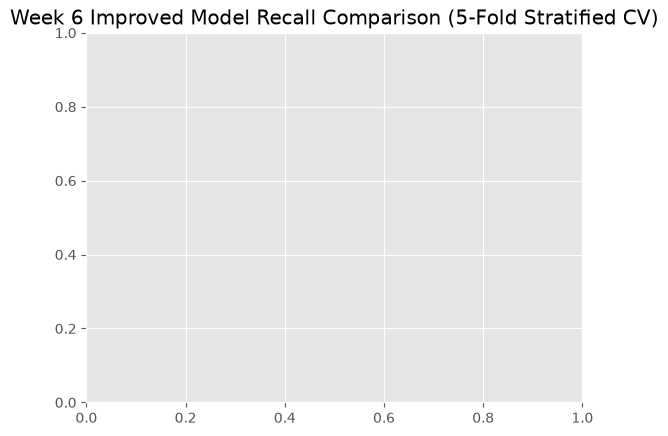

In [9]:
plot_model_comparison(w6_results, save_path=f'{FIGURES_DIR}/fig01_model_comparison_w6.png')
plt.title("Week 6 Improved Model Recall Comparison (5-Fold Stratified CV)")
plt.show()

---
## 6. Integrated Pipeline — Full Execution

In [10]:
pipe = HealthConnectPipeline(threshold=0.50)
results = pipe.run()

2026-09-09 14:55:46 [healthconnect.pipeline] INFO: ============================================================


2026-09-09 14:55:46 [healthconnect.pipeline] INFO: HealthConnect Integrated Pipeline — Starting


2026-09-09 14:55:46 [healthconnect.pipeline] INFO: Model target: Random Forest | Threshold: 0.50


2026-09-09 14:55:46 [healthconnect.pipeline] INFO: ============================================================


2026-09-09 14:55:46 [healthconnect.pipeline] INFO: Dataset loaded: 5000 rows, 18 columns


...

2026-09-09 14:56:19 [healthconnect.pipeline] INFO: Best model selected: Logistic Regression (CV Recall: 0.6280)


2026-09-09 14:56:19 [healthconnect.pipeline] INFO: ============================================================


2026-09-09 14:56:19 [healthconnect.pipeline] INFO: Pipeline execution complete.


2026-09-09 14:56:19 [healthconnect.pipeline] INFO: ============================================================



  Logistic Regression — Evaluation Report
              precision    recall  f1-score   support

    Attended       0.61      0.59      0.60       463
     No-Show       0.62      0.65      0.63       485

    accuracy                           0.62       948
   macro avg       0.62      0.62      0.62       948
weighted avg       0.62      0.62      0.62       948

      accuracy: 0.6171
     precision: 0.6206
        recall: 0.6474
            f1: 0.6337
            f2: 0.6419
       roc_auc: 0.6642


### 6.1 Best Model Evaluation

In [11]:
best_name = results['best_model_name']
print(f"Best model: {best_name}")

Best model: Logistic Regression


In [12]:
plot_confusion_matrix(
    results['y_test'],
    (results['y_prob'] >= 0.50).astype(int),
    best_name,
    save_path=f'{FIGURES_DIR}/fig02_confusion_matrix_w6.png'
)
plt.show()

In [13]:
plot_roc_curve(
    results['y_test'],
    results['y_prob'],
    best_name,
    save_path=f'{FIGURES_DIR}/fig03_roc_curve_w6.png'
)
plt.show()

### 6.2 Feature Importance

In [14]:
if hasattr(pipe.model, 'feature_importances_'):
    plot_feature_importance(
        pipe.feature_names,
        pipe.model.feature_importances_,
        best_name,
        top_n=12,
        save_path=f'{FIGURES_DIR}/fig04_feature_importance_w6.png'
    )
    plt.show()

---
## 7. Prediction Output Validation

In [15]:
preds = results['predictions']
print(f"Prediction rows: {len(preds)}")
print(f"Risk tier distribution:")
print(preds['risk_tier'].value_counts())
validate_prediction_output(preds)
print("Prediction output validation passed.")

2026-09-09 14:56:20 [healthconnect.pipeline] INFO: Prediction output validation passed: 948 predictions


Prediction rows: 948
Risk tier distribution:
risk_tier
MODERATE_RISK    546
LOW_RISK         267
HIGH_RISK        135
Name: count, dtype: int64
Prediction output validation passed.


---
## 8. Single-Record Prediction Test

In [16]:
test_record = {
    "gender": "Female",
    "age": 42,
    "age_group": "35-44",
    "appointment_type": "Follow-up",
    "appointment_day": "Tuesday",
    "appointment_time": "Afternoon",
    "booking_lead_days": 18,
    "previous_appointments": 4,
    "previous_no_shows": 2,
    "reminder_sent": "Yes",
    "reminder_channel": "SMS",
    "distance_to_clinic_km": 14.2,
}
result = pipe.predict_single(test_record)
print(json.dumps(result, indent=2))

{
  "appointment_id": "UNKNOWN",
  "no_show_probability": 0.5628,
  "risk_tier": "MODERATE_RISK",
  "recommended_action": "TRIGGER_SMS_REMINDER_REQUESTING_CONFIRMATION"
}


---
## 9. Pipeline Artifact Saving

In [17]:
pipe.save_artifacts("artifacts")

2026-09-09 14:56:20 [healthconnect.pipeline] INFO: Pipeline artifacts saved to artifacts/


---
## 10. Cross-Track Collaboration

### Collaboration with Data Science Track
- **Track collaborated with:** Data Science
- **Project dependency:** Data Science produces the candidate model and error analysis
  that informs which model and hyperparameters the ML Engineering pipeline should integrate.
- **Information/output received:** Candidate model (Random Forest), error analysis
  identifying false negatives as the primary concern, feature importance confirming
  `booking_lead_days` as the dominant signal.
- **Information/output provided:** Technical constraints on model interface compatibility,
  preprocessing format requirements, and pipeline input/output schema specifications.
- **Integration activity completed:** Integrated the Data Science candidate model
  configuration into `get_improved_models()` and validated the full pipeline flow.
- **What changed as a result:** Week 6 improved models use tuned hyperparameters informed
  by the DS error analysis; the pipeline validates prediction output against the agreed
  schema; and logging provides execution traceability.
- **Evidence:** This notebook, `pipeline/model_integration.py`, `pipeline/validation.py`,
  and the integration test suite (`tests/test_integration.py`).

---
## 11. Week 5 vs Week 6 Comparison

In [18]:
# Final test-set comparison
print("Week 5 Best Model (Logistic Regression):")
print("  Recall: 0.6495, Accuracy: 0.6171, ROC-AUC: 0.6641")
print()
print(f"Week 6 Best Model ({best_name}):")
print(f"  Recall: {results['test_metrics']['recall']:.4f}, Accuracy: {results['test_metrics']['accuracy']:.4f}, ROC-AUC: {results['test_metrics']['roc_auc']:.4f}")

Week 5 Best Model (Logistic Regression):
  Recall: 0.6495, Accuracy: 0.6171, ROC-AUC: 0.6641

Week 6 Best Model (Logistic Regression):
  Recall: 0.6474, Accuracy: 0.6171, ROC-AUC: 0.6642


---
## 12. Assumptions, Limitations, Risks & Dependencies

### Resolved from Week 5
- Validation checks now enforce schema and output correctness.
- Logging provides execution traceability.
- Integrated pipeline is a single callable class.

### Remaining
- `GroupKFold` by `patient_id` is still deferred to Week 7 for rigorous leakage control.
- Production deployment (FastAPI, Docker) is deferred to Week 8.
- Drift monitoring is not yet implemented.

### New Issues Discovered
- `LightGBM` recall dropped slightly under tuned hyperparameters; requires further tuning.
- The pipeline currently holds the best model in memory; persistence to disk is implemented
  but full loading/reloading needs end-to-end validation in Week 7.

---
## 13. Week 7 Testing Requirements
1. End-to-end validation with `GroupKFold` grouped by `patient_id`.
2. Threshold tuning for $F_2$-score optimisation.
3. Model artifact loading and prediction on unseen data.
4. FastAPI inference service integration (containerised).
5. MLflow experiment tracking setup.
6. Evidently AI drift monitoring baseline.